In [1]:
import os
import glob
import hashlib
import numpy as np
from PIL import Image

recon_dir = "/data/akherandish3/Statistical_OOD_detection/results_patches_ddad_native/samples_001/ddad_native_0_4/inpainting/recon"

# Example target directory to compare against (change this to your actual target)
# e.g., original images or a previous run's output
target_dir = "/data/akheirandish3/mvtec_ad/cable/test/combined"

def get_file_hash(filepath):
    """Calculate the MD5 hash of a file to check for exact byte-level changes."""
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def calculate_mse(imageA_path, imageB_path):
    """Calculate the Mean Squared Error between two images to detect pixel changes."""
    try:
        imgA = np.array(Image.open(imageA_path).convert('RGB')).astype("float")
        imgB = np.array(Image.open(imageB_path).convert('RGB')).astype("float")
        err = np.sum((imgA - imgB) ** 2)
        err /= float(imgA.shape[0] * imgA.shape[1])
        return err
    except Exception as e:
        return str(e)

recon_files = sorted(glob.glob(os.path.join(recon_dir, "*.png")))

print(f"Found {len(recon_files)} images in the recon directory.\n")

for recon_path in recon_files:
    filename = os.path.basename(recon_path)
    recon_hash = get_file_hash(recon_path)
    
    # Check if a file with the same name exists in the target directory
    target_path = os.path.join(target_dir, filename)
    
    if os.path.exists(target_path):
        target_hash = get_file_hash(target_path)
        mse_diff = calculate_mse(recon_path, target_path)
        
        if recon_hash == target_hash:
            print(f"[{filename}] NO CHANGES: Exact same file (Hash matched).")
        else:
            print(f"[{filename}] CHANGED: Hash differs. Pixel MSE difference: {mse_diff:.2f}")
    else:
        print(f"[{filename}] Target file for comparison not found (Hash: {recon_hash[:8]}...)")

Found 20 images in the recon directory.

[0_0_00000.png] Target file for comparison not found (Hash: 69f2f59e...)
[10_0_00000.png] Target file for comparison not found (Hash: b196592d...)
[11_0_00000.png] Target file for comparison not found (Hash: 31677a40...)
[12_0_00000.png] Target file for comparison not found (Hash: 42c11905...)
[13_0_00000.png] Target file for comparison not found (Hash: 122c0801...)
[14_0_00000.png] Target file for comparison not found (Hash: d486a1ee...)
[15_0_00000.png] Target file for comparison not found (Hash: fe877886...)
[16_0_00000.png] Target file for comparison not found (Hash: bd1d587c...)
[17_0_00000.png] Target file for comparison not found (Hash: 464e7962...)
[18_0_00000.png] Target file for comparison not found (Hash: b9cb1111...)
[19_0_00000.png] Target file for comparison not found (Hash: ac3255cd...)
[1_0_00000.png] Target file for comparison not found (Hash: 29de8e8b...)
[2_0_00000.png] Target file for comparison not found (Hash: f8b1f9c6...)


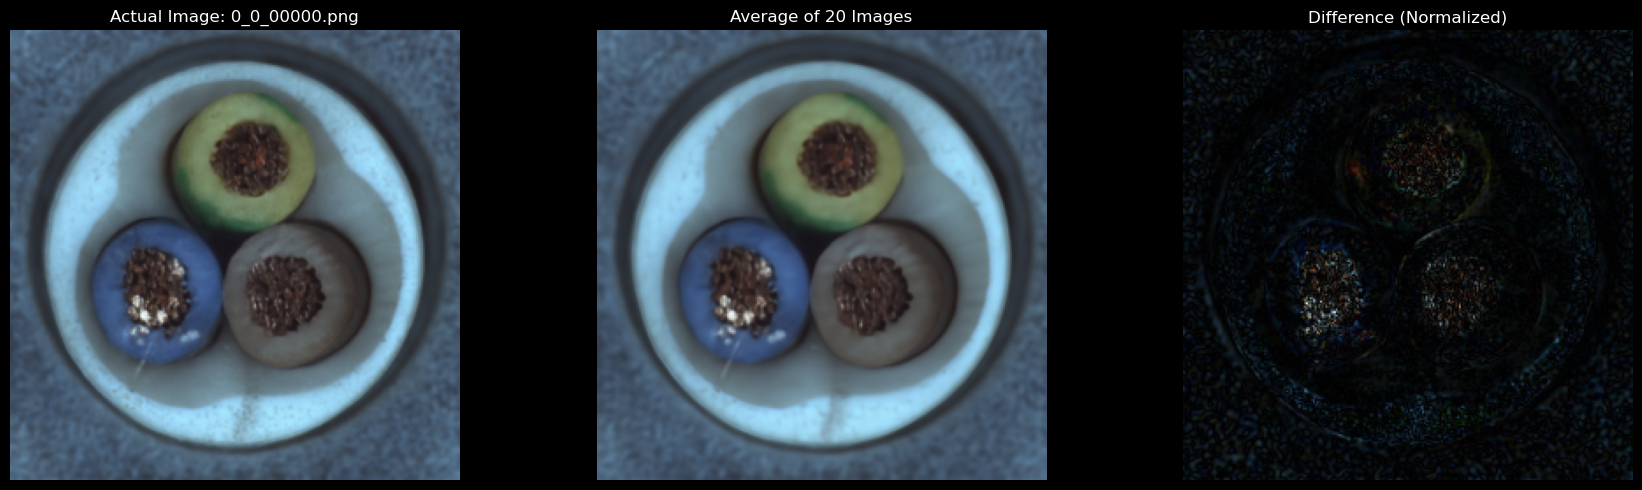

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

recon_dir = "/data/akherandish3/Statistical_OOD_detection/results_patches_ddad_native/samples_001/ddad_native_0_4/inpainting/recon"
recon_files = sorted(glob.glob(os.path.join(recon_dir, "*.png")))

# Load all 20 images into a numpy array
images = []
for file_path in recon_files:
    img = np.array(Image.open(file_path).convert('RGB')).astype("float")
    images.append(img)
    
images = np.array(images)

# Calculate the average image across all 20 images
average_image = np.mean(images, axis=0)

# Pick one actual image for the example (e.g., the first one)
sample_idx = 0
actual_image = images[sample_idx]
sample_filename = os.path.basename(recon_files[sample_idx])

# Calculate the absolute difference between the actual image and the average image
diff_image = np.abs(actual_image - average_image)

# Normalize the difference image so it's easier to see the variations
diff_normalized = (diff_image - diff_image.min()) / (diff_image.max() - diff_image.min() + 1e-8)

# Plot the actual image, the average image, and their difference
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.title(f"Actual Image: {sample_filename}")
plt.imshow(actual_image.astype("uint8"))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Average of 20 Images")
plt.imshow(average_image.astype("uint8"))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Difference (Normalized)")
plt.imshow(diff_normalized)
plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
import json
import argparse
import numpy as np

parser = argparse.ArgumentParser()
# parser.add_argument('--json_path', type=str, default='/data/akherandish3/Statistical_OOD_detection/results_eval_ddad_native_faces/faces_random.json')
# parser.add_argument('--json_path', type=str, default='/data/akherandish3/Statistical_OOD_detection/results_eval_ddad_native_faces/CT_scan.json')
parser.add_argument('--json_path', type=str, default='/data/akherandish3/Statistical_OOD_detection/results_eval_ddad_native_CT_pca_16_resnet_101_autoEncoder_CT/ae_pixel_autoencoder_CT_same_data_CT_scan.json')

# ./results_eval_ddad_native_faces/CT_scan.json
args = parser.parse_args(args=[])

with open(args.json_path, 'r') as f:
    data = json.load(f)

per_sample = data.get('per_sample', {})

# if not per_sample:
#     print("No samples found in JSON.")
#     return

# Collect metrics
metrics = {"raw": {"px_roc_auc": [], "snr": []}, "sigma_5.0": {"px_roc_auc": [], "snr": []}}

for sample_k, sample_v in per_sample.items():
    for sigma_k in ['raw', 'sigma_5.0']:
        if sigma_k in sample_v:
            metrics[sigma_k]['px_roc_auc'].append(sample_v[sigma_k].get('px_roc_auc', np.nan))
            metrics[sigma_k]['snr'].append(sample_v[sigma_k].get('snr', np.nan))

print(f"--- Averages computed over {len(per_sample)} samples ---")
for sigma_k in ['raw', 'sigma_5.0']:
    avg_auc = np.nanmean(metrics[sigma_k]['px_roc_auc'])
    avg_snr = np.nanmean(metrics[sigma_k]['snr'])
    print(f"[{sigma_k}]")
    print(f"  Average Pixel AUC : {avg_auc:.6f}")
    print(f"  Average SNR       : {avg_snr:.6f}")

--- Averages computed over 100 samples ---
[raw]
  Average Pixel AUC : 0.680904
  Average SNR       : 0.813257
[sigma_5.0]
  Average Pixel AUC : 0.722100
  Average SNR       : 0.964469


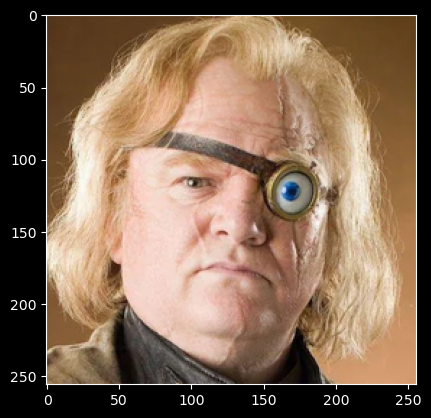

In [5]:
import matplotlib.pyplot as plt
plt.imshow(plt.imread("/data/akheirandish3/mvtec_ad/faces/test/random/92.png"))

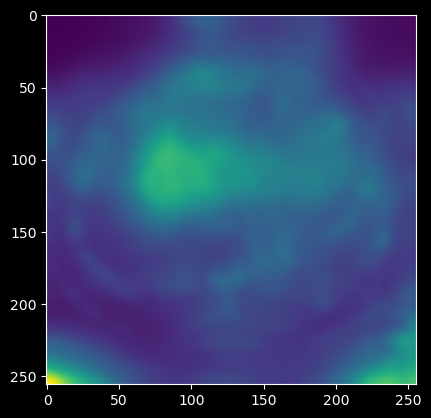

In [26]:
import numpy as np
import matplotlib.pyplot as plt
temp = np.load("/data/akherandish3/Statistical_OOD_detection/DDAD/results/CTsample99_heatmap.npy")
# temp = np.load("/data/akherandish3/Statistical_OOD_detection/DDAD/results/CTsample72_heatmap.npy")
mask = plt.imread("/data/akheirandish3/mvtec_ad/CT/ground_truth/random/image_0083_mask.png")
plt.imshow(temp[0])

In [27]:
print(temp.shape)

(1, 256, 256)


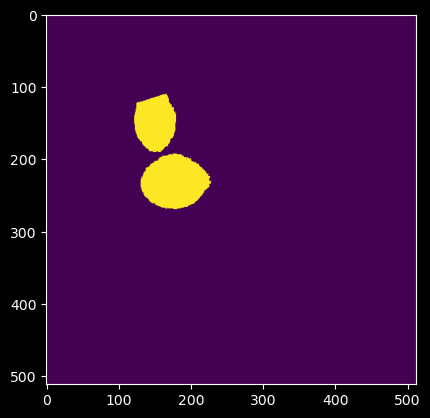

In [28]:
plt.imshow(mask>0.5)

Pixel-level AUROC: 0.9569578620625323


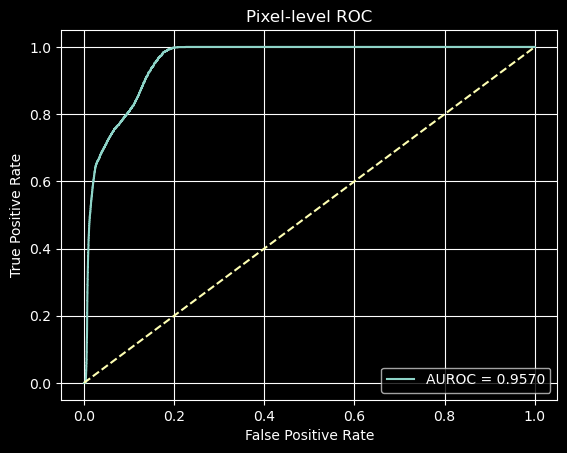

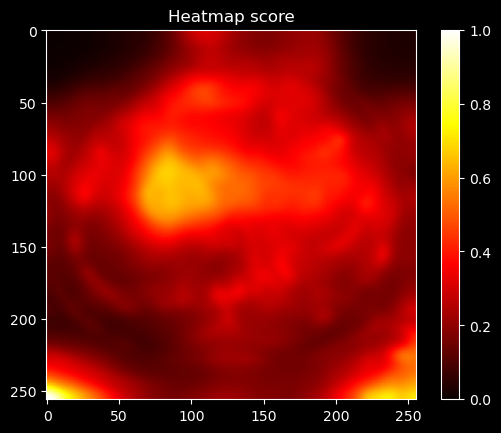

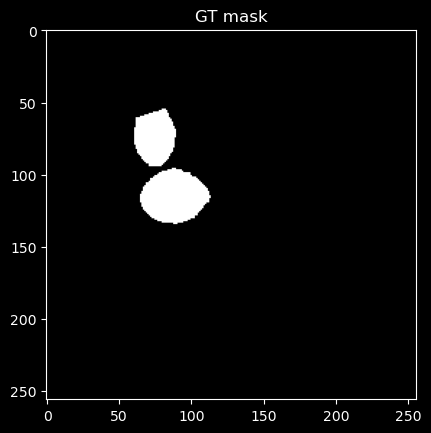

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from skimage.transform import resize
#  If mask is RGB/RGBA, convert to grayscale
if mask.ndim == 3:
    mask = mask[..., 0]
score = temp[0]
# score = (score-min(score.ravel()))/(max(score.ravel())-min(score.ravel())+1e-8)
# Resize mask if needed
if mask.shape != score.shape:
    mask = resize(mask, score.shape, order=0, preserve_range=True, anti_aliasing=True)

# Binarize mask
mask_bin = mask > 0.5

# Flatten
y_true = mask_bin.astype(np.uint8).ravel()
y_score = score.ravel()

# Remove NaN/inf if any
valid = np.isfinite(y_score)
y_true = y_true[valid]
y_score = y_score[valid]

# Compute ROC and AUROC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

print("Pixel-level AUROC:", auc)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"AUROC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Pixel-level ROC")
plt.legend()
plt.grid(True)
plt.show()

# Optional: visualize score and mask
plt.figure()
plt.imshow(score, cmap="hot")
plt.title("Heatmap score")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(mask_bin, cmap="gray")
plt.title("GT mask")
plt.show()

['P04460_OL.png', 'P00460_OL.png', 'P04559_OL.png', 'P04688_OL.png', 'P01088_OL.png', 'P02800_OL.png', 'P01545_OL.png', 'P04639_OL.png', 'P00209_OL.png', 'P04293_OL.png', 'P04060_OL.png', 'P03195_OL.png', 'P01733_OL.png', 'P02904_OL.png', 'P02052_OL.png', 'P00183_OL.png', 'P03686_OL.png', 'P01719_OL.png', 'P03645_OL.png', 'P04548_OL.png']
Number of images: 100
['P04460_OL.png', 'P00460_OL.png', 'P04559_OL.png', 'P04688_OL.png', 'P01088_OL.png', 'P02800_OL.png', 'P01545_OL.png', 'P04639_OL.png', 'P00209_OL.png', 'P04293_OL.png']


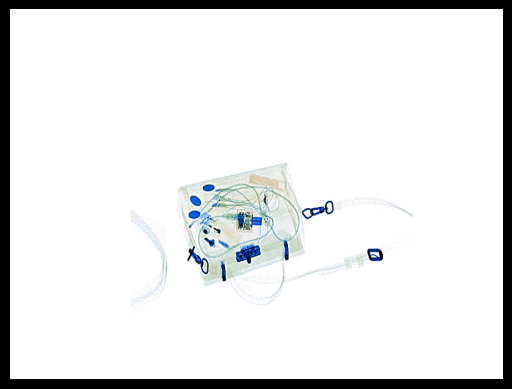

In [ ]:
import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt

img_dir = "/data2/rohan/datasets/sam3_dvxray_n100/images"

# list files
files = os.listdir(img_dir)
print(files[:20])
# plt.imshow(plt.imread("/data2/rohan/datasets/sam3_dvxray_n100/images/"))
image_files = [
    f for f in os.listdir(img_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))
]

print("Number of images:", len(image_files))
print(image_files[:10])

img_path = os.path.join(img_dir, image_files[16])#6 9 10 11 13 16

img = plt.imread(img_path)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [34]:
for i in [6,9,10,11,13,16]:
    img_path = os.path.join(img_dir, image_files[i])
    print(f"Image: {image_files[i]}, Path: {img_path}")
    # img = plt.imread(img_path)
    # plt.imshow(img, cmap="gray")
    # plt.title(f"Image: {image_files[i]}")
    # plt.axis("off")
    # plt.show()

Image: P01545_OL.png, Path: /data2/rohan/datasets/sam3_dvxray_n100/images/P01545_OL.png
Image: P04293_OL.png, Path: /data2/rohan/datasets/sam3_dvxray_n100/images/P04293_OL.png
Image: P04060_OL.png, Path: /data2/rohan/datasets/sam3_dvxray_n100/images/P04060_OL.png
Image: P03195_OL.png, Path: /data2/rohan/datasets/sam3_dvxray_n100/images/P03195_OL.png
Image: P02904_OL.png, Path: /data2/rohan/datasets/sam3_dvxray_n100/images/P02904_OL.png
Image: P03686_OL.png, Path: /data2/rohan/datasets/sam3_dvxray_n100/images/P03686_OL.png


In [36]:
! cp /data2/rohan/datasets/sam3_dvxray_n100/images/P04293_OL.png /data/akheirandish3/mvtec_ad/xray/test/anomaly

In [13]:
import json
from pathlib import Path
import pandas as pd

ROOT = Path("/data/akherandish3/Statistical_OOD_detection/results_ablation_superpixel_200")
OUT_DIR = ROOT / "summary_tables"
OUT_DIR.mkdir(exist_ok=True)

all_rows = []

# Finds files like:
# ae_pixel_autoencoder_bottle_bottle_summary.json
# or any other *_summary.json recursively
summary_files = sorted(ROOT.rglob("*_summary.json"))

print(f"Found {len(summary_files)} summary files")

for path in summary_files:
    with open(path, "r") as f:
        data = json.load(f)

    category = data.get("category", path.stem)

    for row in data.get("rows", []):
        new_row = dict(row)
        new_row["category"] = category
        new_row["source_file"] = str(path)
        all_rows.append(new_row)

df = pd.DataFrame(all_rows)

if df.empty:
    raise RuntimeError("No rows found. Check if *_summary.json files exist under ROOT.")

# Reorder columns
preferred_cols = [
    "category",
    "subcategory",
    "eval_sigma",
    "n",
    "px_roc_auc",
    "sp_roc_auc",
    "px_ap",
    "sp_ap",
    "psnr",
    "snr",
    "source_file",
]
df = df[[c for c in preferred_cols if c in df.columns]]

# Save raw combined table
df.to_csv(OUT_DIR / "all_subcategory_results.csv", index=False)


def weighted_avg(group, col):
    valid = group[[col, "n"]].dropna()
    if valid.empty:
        return float("nan")
    return (valid[col] * valid["n"]).sum() / valid["n"].sum()


# Category-level average for each sigma
category_summary = (
    df.groupby(["category", "eval_sigma"])
    .apply(
        lambda g: pd.Series({
            "total_n": g["n"].sum(),
            "num_subcategories": g["subcategory"].nunique(),
            "px_auc_weighted": weighted_avg(g, "px_roc_auc"),
            "sp_auc_weighted": weighted_avg(g, "sp_roc_auc"),
            "px_ap_weighted": weighted_avg(g, "px_ap"),
            "sp_ap_weighted": weighted_avg(g, "sp_ap"),
            "psnr_weighted": weighted_avg(g, "psnr"),
            "snr_weighted": weighted_avg(g, "snr"),
            "px_auc_mean": g["px_roc_auc"].mean(),
            "sp_auc_mean": g["sp_roc_auc"].mean(),
            "psnr_mean": g["psnr"].mean(),
            "snr_mean": g["snr"].mean(),
        })
    )
    .reset_index()
)

category_summary.to_csv(OUT_DIR / "category_summary_by_sigma.csv", index=False)


# Overall average across all categories for each sigma
overall_summary = (
    df.groupby("eval_sigma")
    .apply(
        lambda g: pd.Series({
            "total_n": g["n"].sum(),
            "num_categories": g["category"].nunique(),
            "num_subcategories": g[["category", "subcategory"]].drop_duplicates().shape[0],
            "px_auc_weighted": weighted_avg(g, "px_roc_auc"),
            "sp_auc_weighted": weighted_avg(g, "sp_roc_auc"),
            "px_ap_weighted": weighted_avg(g, "px_ap"),
            "sp_ap_weighted": weighted_avg(g, "sp_ap"),
            "psnr_weighted": weighted_avg(g, "psnr"),
            "snr_weighted": weighted_avg(g, "snr"),
            "px_auc_mean": g["px_roc_auc"].mean(),
            "sp_auc_mean": g["sp_roc_auc"].mean(),
            "psnr_mean": g["psnr"].mean(),
            "snr_mean": g["snr"].mean(),
        })
    )
    .reset_index()
)

overall_summary.to_csv(OUT_DIR / "overall_summary_by_sigma.csv", index=False)


# Best sigma per category based on pixel AUC
best_by_category = (
    category_summary.sort_values(["category", "px_auc_weighted"], ascending=[True, False])
    .groupby("category")
    .head(1)
    .reset_index(drop=True)
)

best_by_category.to_csv(OUT_DIR / "best_sigma_by_category_px_auc.csv", index=False)


print("\nSaved:")
print(OUT_DIR / "all_subcategory_results.csv")
print(OUT_DIR / "category_summary_by_sigma.csv")
print(OUT_DIR / "overall_summary_by_sigma.csv")
print(OUT_DIR / "best_sigma_by_category_px_auc.csv")

print("\nOverall summary by sigma:")
print(overall_summary.to_string(index=False))

print("\nBest sigma per category using weighted pixel AUC:")
print(best_by_category[["category", "eval_sigma", "total_n", "px_auc_weighted", "psnr_weighted", "snr_weighted"]].to_string(index=False))

Found 15 summary files

Saved:
/data/akherandish3/Statistical_OOD_detection/results_ablation_superpixel_200/summary_tables/all_subcategory_results.csv
/data/akherandish3/Statistical_OOD_detection/results_ablation_superpixel_200/summary_tables/category_summary_by_sigma.csv
/data/akherandish3/Statistical_OOD_detection/results_ablation_superpixel_200/summary_tables/overall_summary_by_sigma.csv
/data/akherandish3/Statistical_OOD_detection/results_ablation_superpixel_200/summary_tables/best_sigma_by_category_px_auc.csv

Overall summary by sigma:
eval_sigma  total_n  num_categories  num_subcategories  px_auc_weighted  sp_auc_weighted  px_ap_weighted  sp_ap_weighted  psnr_weighted  snr_weighted  px_auc_mean  sp_auc_mean  psnr_mean  snr_mean
       raw   1258.0            15.0               73.0         0.909585         0.833804        0.370222        0.407425      15.349739      4.417700     0.907618     0.846269  15.311216  4.385268
 sigma_1.0   1258.0            15.0               73.0     

/tmp/ipykernel_1893078/4090489858.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_1893078/4090489858.py:90: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [14]:
import pandas as pd

path = "/data/akherandish3/Statistical_OOD_detection/results_ablation_superpixel_200/summary_tables/overall_summary_by_sigma.csv"

df = pd.read_csv(path)

sigma5 = df[df["eval_sigma"] == "sigma_5.0"]

print(sigma5.to_string(index=False))

eval_sigma  total_n  num_categories  num_subcategories  px_auc_weighted  sp_auc_weighted  px_ap_weighted  sp_ap_weighted  psnr_weighted  snr_weighted  px_auc_mean  sp_auc_mean  psnr_mean  snr_mean
 sigma_5.0   1258.0            15.0               73.0         0.934451         0.833804        0.452408        0.407425       9.879098      4.393911     0.933124     0.846269   9.872022  4.412523


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image as PIL
from skimage.transform import resize
methods = ["patchcore", "simplenet", "supersimplenet"]
method = methods[0]
sample_name = "P02238"
# ── SET THESE ─────────────────────────────────────────────────────────────────
npy_path   = f"/data2/rohan/baseline_eval_results_v2/mvtec_full/{method}/heatmaps/{sample_name}_amap_smooth.npy"
npy_path   = f"/data2/rohan/baseline_eval_results_v2/mvtec_full/{method}_cable/heatmaps/bent_wire_000_amap_smooth.npy"
npy_path = f"/data2/rohan/baseline_eval_results_v2/mvtec_full/{method}_bottle/heatmaps/broken_large_000_amap_smooth.npy"
# npy_path   = "/data2/rohan/baseline_eval_results_v2/dvxray_scissors/patchcore/heatmaps/P01874_amap_smooth.npy"
image_path = f"/data/akheirandish3/mvtec_ad/xray/test/scissors/{sample_name}_OL.png"
image_path = "/data/akheirandish3/mvtec_ad/bottle/test/broken_large/000.png"
out_path   = "./output_overlay.png"
cmap       = "inferno"
alpha      = 0.55
# ─────────────────────────────────────────────────────────────────────────────

heat = np.load(npy_path).astype(np.float32)
heat = np.nan_to_num(heat, nan=0.0, posinf=0.0, neginf=0.0)
if heat.ndim == 3:
    heat = heat.mean(axis=0)

img = np.array(PIL.open(image_path).convert("RGB"))
img = np.array(PIL.open(image_path).convert("RGB").resize((256, 256)))  # ← resize here
heat = resize(heat, (256, 256), order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)  # ← match heatmap too

vals = heat.ravel()
lo, hi = np.percentile(vals[np.isfinite(vals)], [1, 99])
heat_norm = np.clip((heat - lo) / (hi - lo + 1e-8), 0.0, 1.0)

img_f    = img.astype(np.float32) / 255.0
heat_rgb = plt.get_cmap(cmap)(heat_norm)[..., :3]
overlay  = np.clip((1 - alpha) * img_f + alpha * heat_rgb, 0.0, 1.0)

PIL.fromarray((overlay * 255).astype(np.uint8)).save(out_path)
print(f"Saved: {out_path}")

ValueError: This file contains pickled (object) data. If you trust the file you can load it unsafely using the `allow_pickle=` keyword argument or `pickle.load()`.